# FLIM / confocal image processing for fluorescence lifetime reconstruction

This notebook demonstrates FLIM image reconstruction with `brighteyes_flim.calibrate_h5_file()`. The goal is to show that calibration can be performed without using the legacy reference channel (channel 26), which is no longer available in recent BrightEyes-MCS firmware versions.



## Imports
Import the libraries needed to process the FLIM dataset, both for the acquired sample and for the IRF reference. The data layout is `(Nx, Ny, time bin, detector channel)`.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_flim.tools_phasor as flim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.dataio.mcs as mcs
from scipy.ndimage import shift
from skimage.registration import phase_cross_correlation
from brighteyes_flim import calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts



## Calibrate the sample and reference datasets

In [2]:
TAU_REF = None  # Let the algorithm estimate the reference lifetime directly from the reference data.
CHANNEL_SKEW_TYPE = "phase_cross_correlation"
CHANNEL_SKEW_SOURCE = "irf"
CHANNEL_SKEW_FIT_REFERENCE_CHANNEL = 12
CHANNEL_SKEW_FIT_UPSAMPLING = 10
CHANNEL_SKEW_FIT_APODIZE = False
# CHANNEL_SKEW_SOURCE = np.array(custom_skew_bins, dtype=float)
# If a custom skew array is used, its length must match the calibrated channel count.
OVERWRITE = True

LASER_PERIOD_NS = None
#filename = 

FILE_REFERENCE = r"/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
#FILE_DATA = r'/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5'
FILE_DATA = r'/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/02_Convallaria_DFD_40MHz-17-03-2026-17-03-38.h5'
#FILE_DATA = r'/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/03_Convallaria_DFD_40MHz-17-03-2026-17-07-20.h5'



DATA_KEY = ("data", "data_channels_extra")

# If DATA_KEY includes multiple HDF5 datasets, choose which one to inspect below.
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]

FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type="ref",
    tau_ref=TAU_REF,
    fit_mode="model_shift",
    fit_type="circular",
    channel_skew_type="phase_cross_correlation",
    channel_skew_source="ref",
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=True,
)

Calibrating data keys:   0%|          | 0/2 [00:00<?, ?key/s]

Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

Calibrating data_channels_extra:   0%|          | 0/2 [00:00<?, ?ch/s]

/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/h5_data_calibrator.py:1356: RuntimeWarning: Skipping calibration for data key 'data_channels_extra', channel 0: data histogram has a non-positive or non-finite sum
  ).calibrate()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/h5_data_calibrator.py:1356: RuntimeWarning: Calibration fit failed for data key 'data_channels_extra', channel 1: unable to estimate tau_ref from ref
  ).calibrate()
/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/APR_lib.py:130: UserWarning: Could not determine RMS error between images with the normalized average intensities np.float64(3.5813699683295304) and np.float64(0.0). Either the reference or moving image may be empty.
  shift_vec[i, :], error[i, :], diffphase = phase_cross_correlation(dsetW[:, :, ref], dsetW[:, :, i],


## Inspect the calibrated HDF5 file

In [3]:
#show_h5_structure_html(FILE_WITH_CALIBRATION)  # Disabled here to keep the notebook output compact.


## Load the calibrated data and realign detector channels
Load the calibrated dataset, apply `channel_skew` to realign the detector channels, and then sum the signal across the channel axis.


In [4]:
with h5py.File(FILE_WITH_CALIBRATION,"r") as f:
    
        laser_freq_mhz = float(f["calibration/data"].attrs["laser_freq_in_mhz"]) 
        laser_period_ns = float(f["calibration/data"].attrs["laser_period_in_ns"])
        rangex = f['configurationGUI'].attrs['range_x']
        nx = f['configurationGUI'].attrs['nx']
        pixel_size_x_um= rangex / nx
        nbin = f['configurationGUI'].attrs['timebin_per_pixel']
        dt = f['configurationGUI'].attrs['time_resolution']
        pxdwelltime = dt * nbin

        print(f"Using calibrated laser timing: {laser_freq_mhz :.4f} MHz ({laser_period_ns:.4f} ns)")
    
        print(f.keys())
        data_input = f["data"][:]  # Per-pixel decay histograms, aligned to the excitation timing reference.
        channel_skew = f["calibration/data/channel_skew"][:]
        common_delay_in_bins = f["calibration/data/common_delay_in_bins"][:]
        irf_common_delay_realigned = f["calibration/data/irf_common_delay_realigned"][:]

        print(data_input.shape)
        data_summed_no_alignment = np.sum(data_input,axis=(0,1,2,3,5))
        irf_summed_no_alignment = irf_common_delay_realigned.sum(axis=-1)

        data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0,...]
        irf_summed = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())

        data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0,...]
        irf_summed_rev = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)



        print(data_summed.shape)
        print(irf_summed.shape)
        print("Channel skew correction applied.")



        x_dim, y_dim = data_summed.shape[0], data_summed.shape[1]
        h5_dim = (x_dim, y_dim)
        # h5_dataset_phasor_pix = fil.create_dataset('h5_dataset_phasor_pix', shape=h5_dim, dtype=np.complex128)
        print("Calculating phasor for each pixel...")
        h5_dataset_phasor_pix = flim.calculate_phasor(data_summed[:, :, :],
                                                        harmonic=1)
        irf_phasor=flim.calculate_phasor(irf_summed,harmonic=1)
        print("Phasor calculation completed.")
        print(h5_dataset_phasor_pix.shape)
        print("Freeing memory...")
        del data_input




Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
<KeysViewHDF5 ['calibration', 'configurationFPGA', 'configurationGUI', 'configurationGUI_beforeStart', 'configurationSpadFCSmanager', 'data', 'data_channels_extra', 'thumbnail']>
(1, 1, 501, 501, 91, 25)
(501, 501, 91)
(91,)
Channel skew correction applied.
Calculating phasor for each pixel...
Phasor calculation completed.
(501, 501)
Freeing memory...


## Compare the effect of channel-skew correction

The plots below show the summed IRF and the summed sample signal after channel realignment.

For comparison, the same `channel_skew` values are also applied in the reverse direction.
Only the forward correction improves the temporal alignment, as expected.


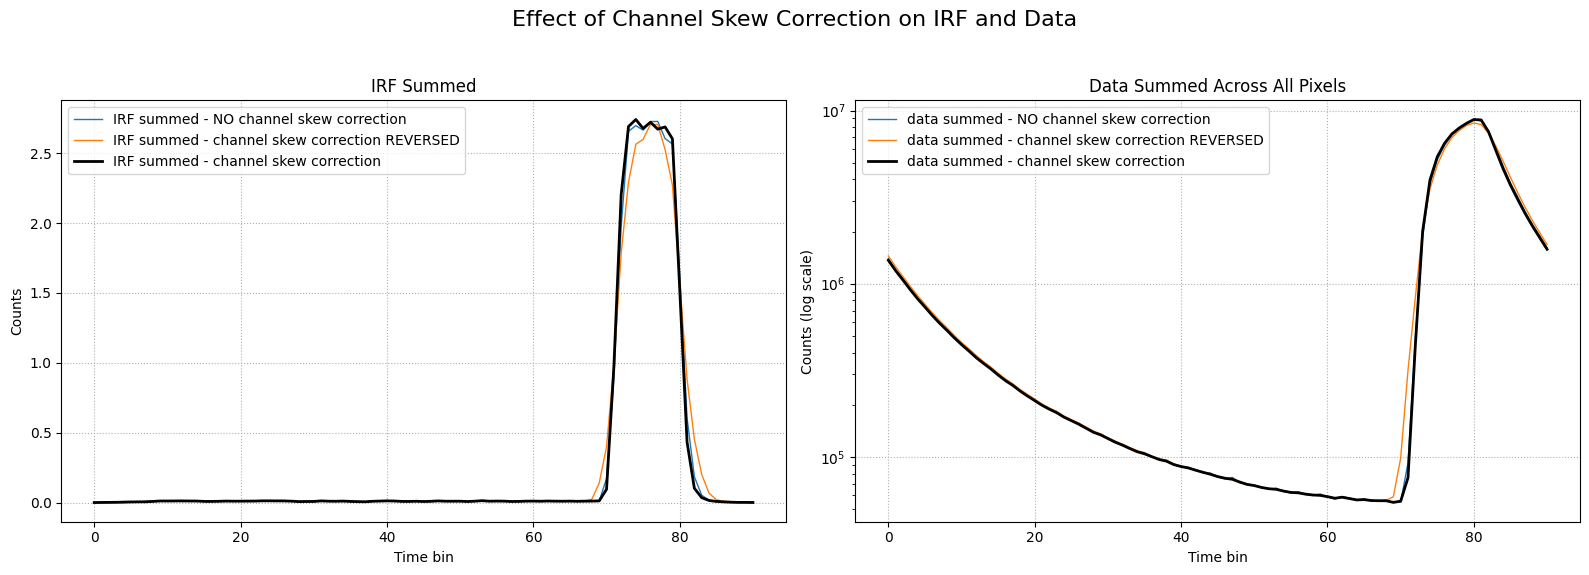

In [5]:
# Compare the summed IRF and data traces before and after channel-skew correction.
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Effect of Channel Skew Correction on IRF and Data", fontsize=16)

# Left panel: IRF traces.
axs[0].plot(irf_summed_no_alignment, label="IRF summed - NO channel skew correction", color='tab:blue', linewidth=1)
axs[0].plot(irf_summed_rev, label="IRF summed - channel skew correction REVERSED", color='tab:orange', linestyle='-', linewidth=1)
axs[0].plot(irf_summed, label="IRF summed - channel skew correction", color='k', linestyle='-', linewidth=2)
axs[0].set_title("IRF Summed")
axs[0].set_xlabel("Time bin")
axs[0].set_ylabel("Counts")
axs[0].legend()
axs[0].grid(True, linestyle=':')

# Right panel: sample data summed over all pixels.
axs[1].plot(data_summed_no_alignment, label="data summed - NO channel skew correction", color='tab:blue', linewidth=1)
axs[1].plot(data_summed_rev.sum(axis=(0,1)), label ="data summed - channel skew correction REVERSED", color='tab:orange', linestyle='-', linewidth=1)
axs[1].plot(data_summed.sum(axis=(0,1)), label ="data summed - channel skew correction", color='k', linestyle='-', linewidth=2)
axs[1].set_title("Data Summed Across All Pixels")
axs[1].set_xlabel("Time bin")
axs[1].set_ylabel("Counts (log scale)")
axs[1].set_yscale("log")
axs[1].legend()
axs[1].grid(True, linestyle=':')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Compute intensity, phasor, and lifetime maps
Use the realigned histograms to derive the confocal intensity map, normalize the IRF phasor, and compute the corrected phasor and lifetime maps.


In [6]:
intensity_map = data_summed.sum(axis=-1)                # Confocal intensity image.
irf_phasor_norm = irf_phasor/abs(irf_phasor)            # Normalize the IRF phasor to unit magnitude.
phasor_map = h5_dataset_phasor_pix / irf_phasor    # Correct the sample phasor using the IRF phasor.


In [7]:
# Apply an intensity threshold to suppress low-signal pixels in the plots.

threshold = 0.05
thresholded_phasor_map = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
lifetime_map = flim.calculate_tau_m(phasor_map, dfd_freq = laser_freq_mhz) * 1e3 # ns
thresholded_tau_map = flim.calculate_tau_m(thresholded_phasor_map, dfd_freq=laser_freq_mhz) * 1e3
thresholded_tau_map = thresholded_tau_map[np.isfinite(thresholded_tau_map)]


/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


## Visualize the FLIM reconstruction
Display the confocal intensity, lifetime map, phasor plot, and lifetime histogram for the realigned dataset.


/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/Graph_lib.py:687: RuntimeWarning: invalid value encountered in cast
  idx = (np.floor((variable - self.var_bounds[0]) / (self.var_bounds[1] - self.var_bounds[0]) * N)).astype(int)


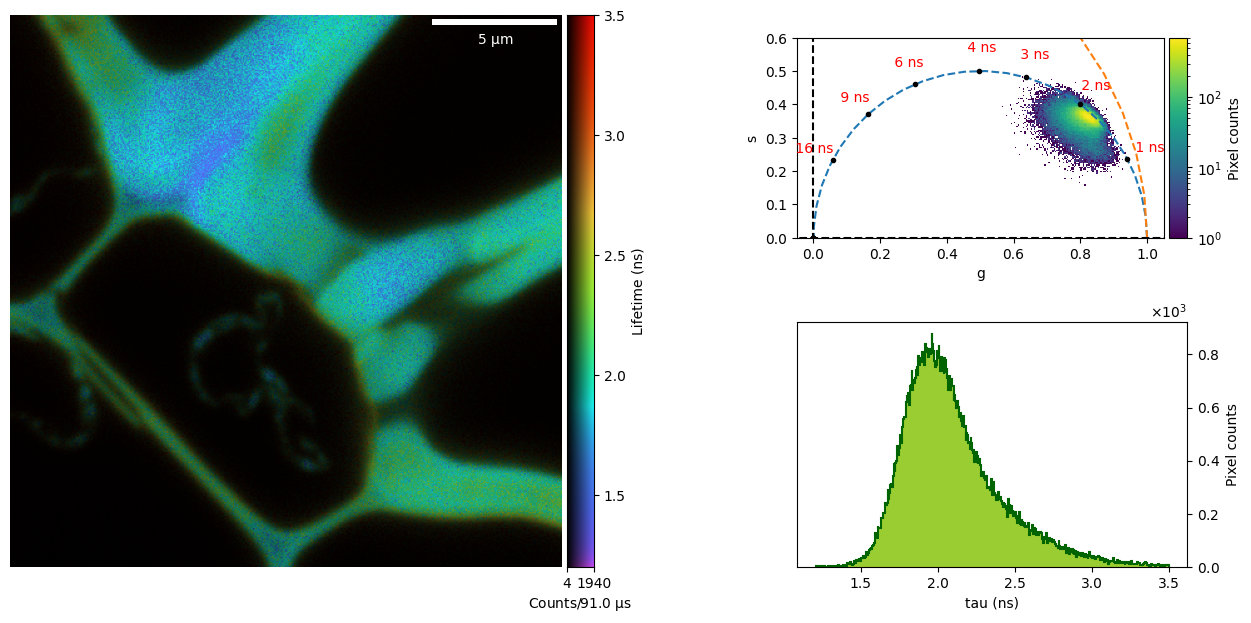

In [8]:
from matplotlib.ticker import ScalarFormatter

crop = 30
cmap = 'turbo'

lower_bound = 1.2
upper_bound = 3.5

bin_plot = 500

fig = plt.figure(figsize = (18, 12))
gs = fig.add_gridspec(4, 4)

ax1 = fig.add_subplot(gs[0:2, 0:2])


gra.show_flim(intensity_map[crop:-crop, crop:-crop], lifetime_map[crop:-crop, crop:-crop], pixel_size_x_um, pxdwelltime, lifetime_bounds = [lower_bound,upper_bound], fig = fig, ax = ax1, colormap=cmap)

ax3 = fig.add_subplot(gs[0, 2:3])
ax4 = fig.add_subplot(gs[1, 2:3])

flim.plot_phasor(thresholded_phasor_map, quadrant='first', bins_2dplot = bin_plot, cmap='viridis', dfd_freq = laser_freq_mhz*1e6,  fig = fig, ax = ax3)
# Alternative histogram call kept here for quick experimentation.
ax4.hist(thresholded_tau_map, 
       # weights=thresholded_intensity_map,
        bins = 500,
        range=(lower_bound, upper_bound), histtype='step', fill=True, fc='yellowgreen',
        edgecolor='darkgreen', linewidth=1.5)

ax4.yaxis.tick_right()
ax4.yaxis.set_label_position("right")
ax4.set_xlabel('tau (ns)')
ax4.set_ylabel('Pixel counts')
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((3,3))
ax4.yaxis.set_major_formatter(sf)




## Optional: equalized FLIM rendering


The equalized FLIM plotting helpers used below are implemented in `brighteyes_flim.tools_phasor`.



/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:873: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_2069214/3602350292.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


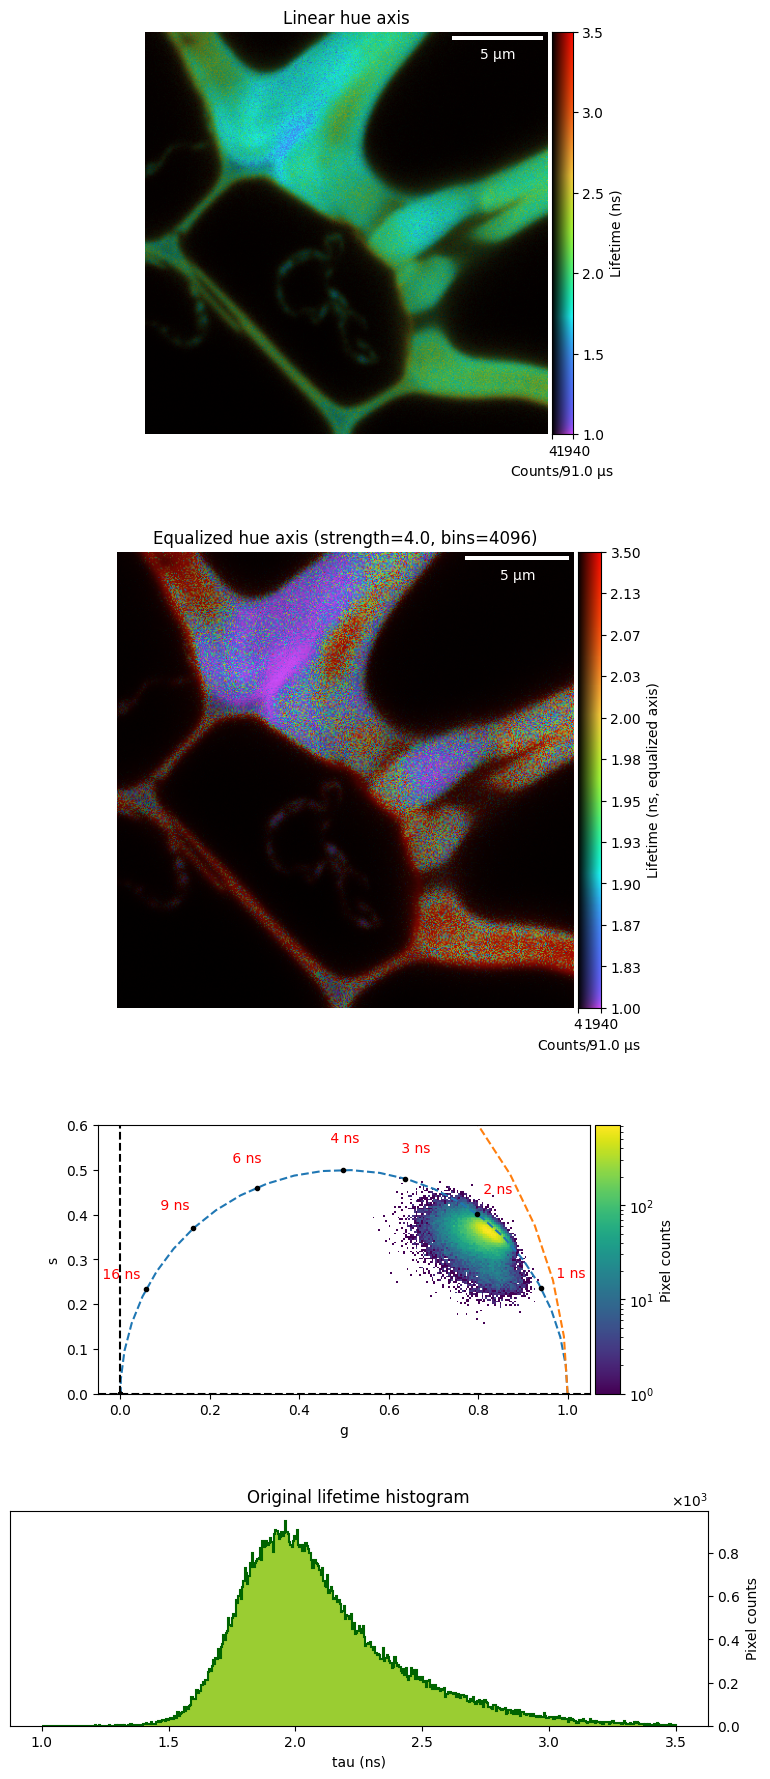

In [9]:
from matplotlib.ticker import ScalarFormatter

crop = 30
cmap = 'turbo'
equalization_strength = 4.0
equalization_bins = 4096
equalization_tick_count = 12

lower_bound = 1.0
upper_bound = 3.5
lifetime_bounds = [lower_bound, upper_bound]

bin_plot = 500

display_intensity = intensity_map[crop:-crop, crop:-crop]
display_lifetime = lifetime_map[crop:-crop, crop:-crop]
equalization_reference = thresholded_tau_map

fig = plt.figure(figsize=(9, 22))
gs = fig.add_gridspec(4, 1, height_ratios=[1.5, 1.7, 1.0, 0.8], hspace=0.35)


ax1 = fig.add_subplot(gs[0, 0])
gra.show_flim(
    display_intensity,
    display_lifetime,
    pixel_size_x_um,
    pxdwelltime,
    lifetime_bounds=lifetime_bounds,
    fig=fig,
    ax=ax1,
    colormap=cmap,
)
ax1.set_title('Linear hue axis')

ax2 = fig.add_subplot(gs[1, 0])
flim.show_flim_equalized(
    display_intensity,
    display_lifetime,
    pixel_size_x_um,
    pxdwelltime,
    lifetime_bounds=lifetime_bounds,
    fig=fig,
    ax=ax2,
    colormap=cmap,
    equalization_reference=equalization_reference,
    equalization_strength=equalization_strength,
    equalization_bins=equalization_bins,
    colorbar_ticks=equalization_tick_count,
)
ax2.set_title(
    f'Equalized hue axis (strength={equalization_strength:.1f}, bins={equalization_bins})'
)

ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[3, 0])

flim.plot_phasor(
    thresholded_phasor_map,
    quadrant='first',
    bins_2dplot=bin_plot,
    cmap='viridis',
    dfd_freq=laser_freq_mhz * 1e6,
    fig=fig,
    ax=ax3,
)

ax4.hist(
    thresholded_tau_map,
    bins=500,
    range=(lower_bound, upper_bound),
    histtype='step',
    fill=True,
    fc='yellowgreen',
    edgecolor='darkgreen',
    linewidth=1.5,
)
ax4.yaxis.tick_right()
ax4.yaxis.set_label_position('right')
ax4.set_xlabel('tau (ns)')
ax4.set_ylabel('Pixel counts')
ax4.set_title('Original lifetime histogram')
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((3, 3))
ax4.yaxis.set_major_formatter(sf)
fig.tight_layout()
